In [21]:
FPGA_ID='100t'

In [22]:
import chipwhisperer as cw
scope = cw.scope()
scope.gain.db = 25
scope.adc.samples = 1500
scope.adc.offset = 0
# scope.adc.timeout = 50
scope.adc.basic_mode = "rising_edge"
scope.trigger.triggers = "tio4"
scope.io.tio1 = "serial_rx"
scope.io.tio2 = "serial_tx"
scope.io.hs2 = "disabled"

In [23]:
import io

default_bsfile = "/home/mdphuc/chipwhisperer/hardware/victims/cw305_artixtarget/fpga/vivado_examples/aes128_verilog/aes128_verilog.runs/impl_100t/cw305_top.bit"
secworks_bsfile = "/home/mdphuc/UCDASEC/SCA/AES_Implementation/AESHardware/CW305_SecWorks/CW305_SecWorks_Vivado/CW305_SecWorks.runs/impl_1/cw305_top.bit"
ProjectVault_bsfile = "/home/phucmai/ProjectVault.bit"
SMAesH_bsfile_DONT_TOUCH = "/home/phucmai/SMAesH_wo_endian_reverse_DONT_TOUCH.bit"
SMAesH_bsfile_optimized = "/home/phucmai/SMAesH_wo_endian_reverse_optimized.bit"
SMAesH_bsfile_optimized_output_seed = "/home/phucmai/SMAesH_wo_endian_reverse_optimized_output_seed.bit"
SMAesH_bsfile_DONT_TOUCH_new_way_to_update_seed = "/home/phucmai/SMAesH_wo_endian_reverse_DONT_TOUCH_new_way_to_update_seed.bit"
SMAesH_bsfile_DONT_TOUCH_in_ready_trigger = "/home/phucmai/SMAesH_wo_endian_reverse_in_ready_trigger_DONT_TOUCH.bit"
SMAesH_bsfile_DONT_TOUCH_round_trigger = "/home/phucmai/SMAesH_wo_endian_reverse_round_trigger_DONT_TOUCH.bit"
SMAesH_bsfile_DONT_TOUCH_crypt_start_trigger = "/home/phucmai/SMAesH_wo_endian_reverse_crypt_start_trigger_DONT_TOUCH.bit"
SMAesH_challenge_bsfile = "/home/mdphuc/UCDASEC/SCA/AES_Implementation/AESHardware/CW305_SMAesH/CW305_SMAesH_challenge_Vivado/CW305_SMAesH_challenge_Vivado.runs/impl_1/cw305_top.bit"
cnn_bsfile = "/home/phucmai/cnn.bit"
cw305_middlemen_bsfile = "/home/phucmai/CW305_middleman.bit"
cw305_uart_bsfile = "/home/phucmai/CW305_UART.bit"

bsfile = SMAesH_bsfile_DONT_TOUCH_new_way_to_update_seed

target = cw.target(scope, cw.targets.CW305, fpga_id=FPGA_ID, bsfile=bsfile, force=True)



(ChipWhisperer NAEUSB WARNING|File naeusb.py:826) Your firmware (0.32.0) is outdated - latest is 0.53.0 See https://chipwhisperer.readthedocs.io/en/latest/firmware.html for more information
(ChipWhisperer Target WARNING|File CW305.py:596) Using default Verilog defines (/home/phucmai/chipwhisperer/software/chipwhisperer/hardware/firmware/cw305/cw305_aes_defines.v); if this is not what you want, provide them via the defines_files argument


In [24]:
target.vccint_set(1.0)
# we only need PLL1:
target.pll.pll_enable_set(True)
target.pll.pll_outenable_set(False, 0)
target.pll.pll_outenable_set(True, 1)
target.pll.pll_outenable_set(False, 2)

# run at 10 MHz:
target.pll.pll_outfreq_set(10E6, 1)

# 1ms is plenty of idling time
target.clkusbautooff = True
target.clksleeptime = 1

In [36]:
import time
for i in range(10):
    scope.clock.reset_adc()
    time.sleep(1)
    if scope.clock.adc_locked:
        break 
assert (scope.clock.adc_locked), "ADC failed to lock"

In [37]:
# CLOCK version 2

if scope._is_husky:
    scope.clock.clkgen_freq = 40e6
    scope.clock.clkgen_src = 'extclk'
    scope.clock.adc_mul = 4
    # if the target PLL frequency is changed, the above must also be changed accordingly
else:
    scope.clock.clkgen_freq = 96e6 / 4
    scope.clock.clkgen_src = "extclk"
    scope.clock.adc_src = "clkgen_x4"
    
    # scope.clock.clkgen_freq = 96e6

In [38]:
print("Capture rate: "+str
      (scope.clock.adc_freq/10e5)+"MHz")
print(scope.clock)

Capture rate: 96.003879MHz
adc_src       = clkgen_x4
adc_phase     = 0
adc_freq      = 96003879
adc_rate      = 96003879.0
adc_locked    = True
freq_ctr      = 10000396
freq_ctr_src  = extclk
clkgen_src    = extclk
extclk_freq   = 10000000
clkgen_mul    = 12
clkgen_div    = 5
clkgen_freq   = 24000000.0
clkgen_locked = True



<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
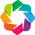

:DynamicMap   []
   :Curve   [index]   (y)

In [42]:
%run "/home/phucmai/chipwhisperer/jupyter/Helper_Scripts/plot.ipynb"
plot = real_time_plot(plot_len=24000)

In [43]:
def text_out_to_hex_string(input_arr):
    hex_str = ""
    for i in range(len(input_arr)):
        if len(str(hex(input_arr[i]))[2:]) == 1:
            hex_str += "0" + str(hex(input_arr[i]))[2:]
        else:
            hex_str += str(hex(input_arr[i]))[2:]

    return hex_str

# 40bfabf406ee4d3042ca6b997a5c5816

In [68]:
### from tqdm.notebook import tnrange
import numpy as np
import time
from Crypto.Cipher import AES
from tqdm import tnrange
import os

previous_dataset = None
N = 100000  # Number of traces

def endian_reverse(array):
    return array[::-1]

if previous_dataset != None:
    dataset = np.load(previous_dataset)
    power_trace = list(dataset["power_trace"])
    plain_text = list(dataset["plain_text"])
    key = dataset["key"]
    plaint_text_hex_str = []
    for plaintext in plain_text:
        plaint_text_hex_str.append(text_out_to_hex_string(plaintext))
    print("Current dataset size: ", len(power_trace))
else:
    power_trace, plain_text, text_out = [],[], []
    plaint_text_hex_str = []

################## K1 ####################
# key_str = "2b,7e,15,16,28,ae,d2,a6,ab,f7,15,88,09,cf,4f,3c"
# key = [0x2b, 0x7e, 0x15, 0x16, 0x28, 0xae, 0xd2, 0xa6, 0xab, 0xf7, 0x15, 0x88, 0x09, 0xcf, 0x4f, 0x3c]
# text = [0x6b, 0xc1, 0xbe, 0xe2, 0x2e, 0x40, 0x9f, 0x96, 0xe9, 0x3d, 0x7e, 0x11, 0x73, 0x93, 0x17, 0x2a]

################## K2 ####################
key_str = "d2,d5,01,68,82,83,91,43,96,9e,e9,a2,53,a7,52,e1"
key_str = ",".join(key_str.split(",")[::-1])
key = [0xd2, 0xd5, 0x01, 0x68, 0x82, 0x83, 0x91, 0x43, 0x96, 0x9e, 0xe9, 0xa2, 0x53, 0xa7, 0x52, 0xe1][::-1]
text = [0x6b, 0xc1, 0xbe, 0xe2, 0x2e, 0x40, 0x9f, 0x96, 0xe9, 0x3d, 0x7e, 0x11, 0x73, 0x93, 0x17, 0x2a]

ktp.setInitialKey(key_str)
ktp.fixed_key = True


# initialize cipher to verify DUT result:
key, text = ktp.next()
# cipher = AES.new(bytes(key), AES.MODE_ECB)
# print(text_out_to_hex_string(key))
# image = [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 17, 47, 47, 47, 16, 129, 85, 47, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 75, 153, 217, 253, 253, 253, 215, 246, 253, 253, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 35, 142, 244, 252, 253, 253, 253, 253, 253, 253, 253, 253, 253, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 63, 253, 253, 253, 253, 253, 253, 253, 213, 170, 170, 170, 170, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 20, 132, 72, 0, 57, 238, 227, 238, 168, 124, 69, 20, 11, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 11, 206, 253, 78, 0, 0, 32, 0, 30, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 6, 177, 253, 132, 10, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 12, 133, 253, 233, 15, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 92, 253, 223, 28, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 150, 253, 174, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 234, 253, 246, 127, 49, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 255, 253, 253, 253, 251, 147, 91, 121, 85, 42, 42, 85, 28, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 139, 253, 253, 253, 253, 253, 253, 253, 253, 253, 253, 253, 232, 168, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3, 53, 218, 222, 251, 253, 253, 253, 253, 253, 253, 253, 253, 252, 124, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 67, 72, 200, 253, 253, 253, 253, 253, 253, 253, 175, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 120, 253, 249, 152, 51, 164, 253, 253, 175, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 50, 253, 253, 253, 188, 252, 253, 253, 148, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 9, 167, 253, 253, 253, 253, 250, 175, 11, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 23, 180, 231, 253, 221, 128, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 93, 149, 22, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
# image_127_0 = image[-127:]
for i in tnrange(N if previous_dataset==None else N - len(dataset["plain_text"]), desc='Capturing traces'):
    # run aux stuff that should come before trace here
    os.system("touch ~/state.log")
    with open("/home/phucmai/state.log", "w") as f:
        if previous_dataset != None:
            f.write("Running with plaintext {0}".format(i + len(dataset["plain_text"])))
        else:
            f.write("Running with plaintext {0}".format(i))

    while text_out_to_hex_string(text) in plaint_text_hex_str:
       key, text = ktp.next()  # manual creation of a key, text pair can be substituted here

    # FOR ProjectVault
    # trace = cw.capture_trace(scope, target, text, key)
    # FOR SMAesH
    text = text[::-1]
    trace = cw.capture_trace(scope, target, bytes(text[::-1]), bytes(key))
    # FOR CNN
    # trace = cw.capture_trace(scope, target, bytes(0), bytes(image))

    power_trace.append(np.array(trace[0],dtype=np.float32))
    plain_text.append(np.array(trace[1]))
    plaint_text_hex_str.append(text_out_to_hex_string(trace[1]))

    time.sleep(0.15)


    ## send trace for visualization every 100th trace
    if i % 100 == 0:
        plot.send(trace)
    time.sleep(0.15)

        
key = np.array(key)  ## as key in all iterations are the same
power_trace = np.array(power_trace,dtype=np.float32)
plain_text = np.array(plain_text)

print(f"Length power trace = {len(power_trace)}")

print(f'Key: {text_out_to_hex_string(key)}')
print(f'Text: {text_out_to_hex_string(text)}')


# used to save the data
import os
output_path='/home/phucmai/'
os.makedirs(output_path, exist_ok=True)
outpath = os.path.join(output_path, 'CW305_SMAesH_96MHz_test_without_endian_reverse_100k_K2.npz')
np.savez(outpath, power_trace=power_trace, plain_text=plain_text,key=key)

/tmp/ipykernel_42273/4128994164.py:48: TqdmDeprecationWarning: Please use `tqdm.notebook.trange` instead of `tqdm.tnrange`
  for i in tnrange(N if previous_dataset==None else N - len(dataset["plain_text"]), desc='Capturing traces'):


Capturing traces:   0%|          | 0/100000 [00:00<?, ?it/s]

Length power trace = 100000
Key: e152a753a2e99e96439183826801d5d2
Text: f7a49e6fcc2936650f2351da4f4b0c3b


In [281]:
# Run this to get the real number of cycles that the design needed to finish its operation
print(scope.adc.trig_count)

175


In [19]:
scope.dis()

True

In [20]:
target.dis()

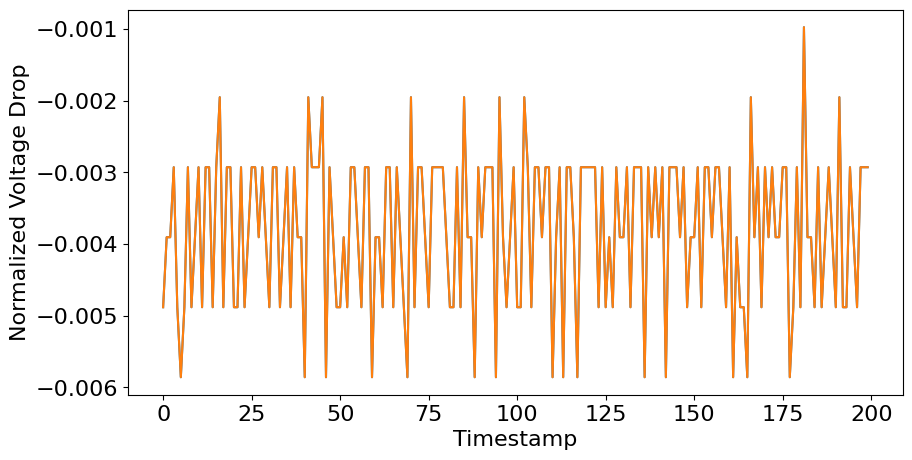

In [72]:
import matplotlib.pyplot as plt
import numpy as np
# power_trace = np.load(os.path.join(output_path, 'CW305_SMAesH_96MHz_v2_200k.npz'))["power_trace"]
plt.rcParams.update({'font.size': 16})
plt.figure(figsize=(10,5))
plt.clf()
plt.xlabel("Timestamp")
plt.ylabel("Normalized Voltage Drop")

# print(power_trace.shape)

for i in range(1):
    plt.plot(power_trace[i])
plt.plot(power_trace[-1])

